In [1]:
from rich import print as rprint
from rich.table import Table
import pandas as pd
from rich.pretty import pprint
from pathlib import Path

# if config_variable == "highlevel":
#     from rosbags.highlevel import AnyReader as ReaderClass
# elif config_variable == "rosbag2":
#     from rosbags.rosbag2 import Reader as ReaderClass
# else:
#     raise ValueError("Invalid config variable value")


from rosbags.typesys import get_types_from_msg, register_types
from rosbags.rosbag2 import Reader
# from rosbags.highlevel import AnyReader as Reader
from rosbags.serde import deserialize_cdr

#### Register custom ROS2 messages

In [2]:
def guess_msgtype(path: Path) -> str:
    """
    Guesses the message type based on the file path.

    Args:
        path (Path): The path to the file.

    Returns:
        str: The guessed message type.
    """
    name = path.relative_to(path.parents[2]).with_suffix("")
    if "msg" not in name.parts:
        name = name.parent / "msg" / name.name
    return str(name)


add_types = {}

for pathstr in Path("/workspaces/molisensext_analysis/data/0external/lufft_wsx_interfaces/msg").glob("**/*"):
    msgpath = Path(pathstr)
    msgdef = msgpath.read_text(encoding="utf-8")
    add_types.update(get_types_from_msg(msgdef, guess_msgtype(msgpath)))

register_types(add_types)

from rosbags.typesys.types import lufft_wsx_interfaces__msg__LufftWSXXX as LufftWSXXX

# print(help(LufftWSXXX))

#### Load Metadata from Bagfile

In [3]:
bag_file = (
    "/workspaces/molisensext_analysis/data/0external/ubuntu2004_bagfiles/molisens_met_2023_04_14-09_23_34_converted"
)

In [4]:
# Crete output table
table = Table(title="Content of bag file")
table.add_column("Topic", style="cyan")
table.add_column("MSG", style="magenta")


# create reader instance and open for reading
topics = []
with Reader(bag_file) as reader:
    # topic and msgtype information is available on .connections list
    for connection in reader.connections:
        topics.append(connection.topic)

        table.add_row(connection.topic, connection.msgtype)
        # print(f'{reader.compression_format=}')
        # print(f'{reader.compression_mode=}')
        # print(f'{reader.custom_data=}')
        # print(f'{reader.start_time=}')
        # print(f'{reader.end_time=}')
        # print(f'{reader.duration=}')
        # print(f'{reader.files=}')
        # print(f'{reader.message_count=}')
        # print(f'{reader.metadata=}')
        # print(f'{reader.topics=}')


rprint(table)

                                Content of bag file                                
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Topic                                     ┃ MSG                                 ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ /clock                                    │ rosgraph_msgs/msg/Clock             │
│ /tf                                       │ tf2_msgs/msg/TFMessage              │
│ /diagnostics                              │ diagnostic_msgs/msg/DiagnosticArray │
│ /rosout                                   │ rcl_interfaces/msg/Log              │
│ /sensing/lidar/points2                    │ sensor_msgs/msg/PointCloud2         │
│ /sensing/aws/ws100_measurements           │ lufft_wsx_interfaces/msg/LufftWSXXX │
│ /sensing/aws/ws501_measurements           │ lufft_wsx_interfaces/msg/LufftWSXXX │
│ /sensing/lidar/points                     │ sensor_msgs/msg/PointCloud2         │
│ /sensing/lidar/os_replay/transition_event │ lifecycle_msgs/msg/TransitionEvent  │
│ /sensing/radar/points                     │ sensor_msgs/msg/PointCloud2         │
│ /tf_static                                │ tf2_msgs/msg/TFMessage              │
└───────────────────────────────────────────┴─────────────────────────────────────┘

In [5]:
def msg_decoder(msg):
    """Extracts data from a ROS message.

    Args:
        msg: ROS message whose data will be extracted.

    Returns:
        Dictionary whose keys are tuples of the form (msg_type, measurement_name) and whose values are the value of the measurement in that message.
    """
    msg_data = {}
    for msg_type, msg_content in msg.__dict__.items():
        # Exclude header and __msgtype__ fields as they are special fields
        if msg_type == "header" or msg_type == "__msgtype__":
            continue

        # msg_data[field_name] = {}
        for field, value in msg_content.__dict__.items():
            if field == "__msgtype__":
                continue

            if field.endswith("_valid") and value == True:
                measurement_name = field.rsplit("_", 1)[0]
                msg_data[(msg_type, measurement_name)] = getattr(msg_content, measurement_name)

    return msg_data

In [6]:
data = {}

with Reader(bag_file) as reader:
    connections = [x for x in reader.connections if x.topic == "/sensing/aws/ws100_measurements"]
    for connection, timestamp, rawdata in reader.messages(connections=connections):
        msg = deserialize_cdr(rawdata, connection.msgtype)
        # print(msg.header.frame_id)
        timestamp = pd.to_datetime(
            msg.header.stamp.sec * 1e9 + msg.header.stamp.nanosec,
            unit="ns",
            origin="unix",
        )

        data[timestamp] = msg_decoder(msg)

df = pd.DataFrame(data).T

In [8]:
df.precipitation.columns

Index(['absolute', 'differential', 'type', 'code', 'intensity_hour',
       'intensity_minute', 'total_precipitation_particles', 'total_drops',
       'drizzle_particles', 'snow_particles', 'hail_particles', 'rain_class_0',
       'rain_class_1', 'rain_class_2', 'rain_class_3', 'rain_class_4',
       'rain_class_5', 'rain_class_6', 'rain_class_7', 'rain_class_8',
       'rain_class_9', 'rain_class_10', 'rain_class_11'],
      dtype='object')

In [9]:
df.precipitation.loc[:, "absolute":"total_drops"]

,absolute,differential,type,code,intensity_hour,intensity_minute,total_precipitation_particles,total_drops
2023-04-14 07:23:40.220463616,0.55,0.0,70.0,71.0,0.58,0.009667,0.0,0.0
2023-04-14 07:23:41.229330944,0.55,0.0,70.0,71.0,0.58,0.009667,1.0,0.0
2023-04-14 07:23:42.215713024,0.55,0.0,70.0,71.0,0.58,0.009667,1.0,0.0
2023-04-14 07:23:43.227717376,0.55,0.0,70.0,71.0,0.58,0.009667,0.0,0.0
2023-04-14 07:23:44.231320832,0.55,0.0,70.0,71.0,0.58,0.009667,1.0,1.0
...,...,...,...,...,...,...,...,...
2023-04-14 08:28:20.225325824,1.36,0.0,70.0,71.0,0.54,0.009000,0.0,0.0
2023-04-14 08:28:21.231252736,1.36,0.0,70.0,71.0,0.54,0.009000,0.0,0.0
2023-04-14 08:28:22.239988736,1.36,0.0,70.0,71.0,0.54,0.009000,0.0,0.0
2023-04-14 08:28:23.225153792,1.36,0.0,70.0,71.0,0.54,0.009000,0.0,0.0


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >], dtype=object)

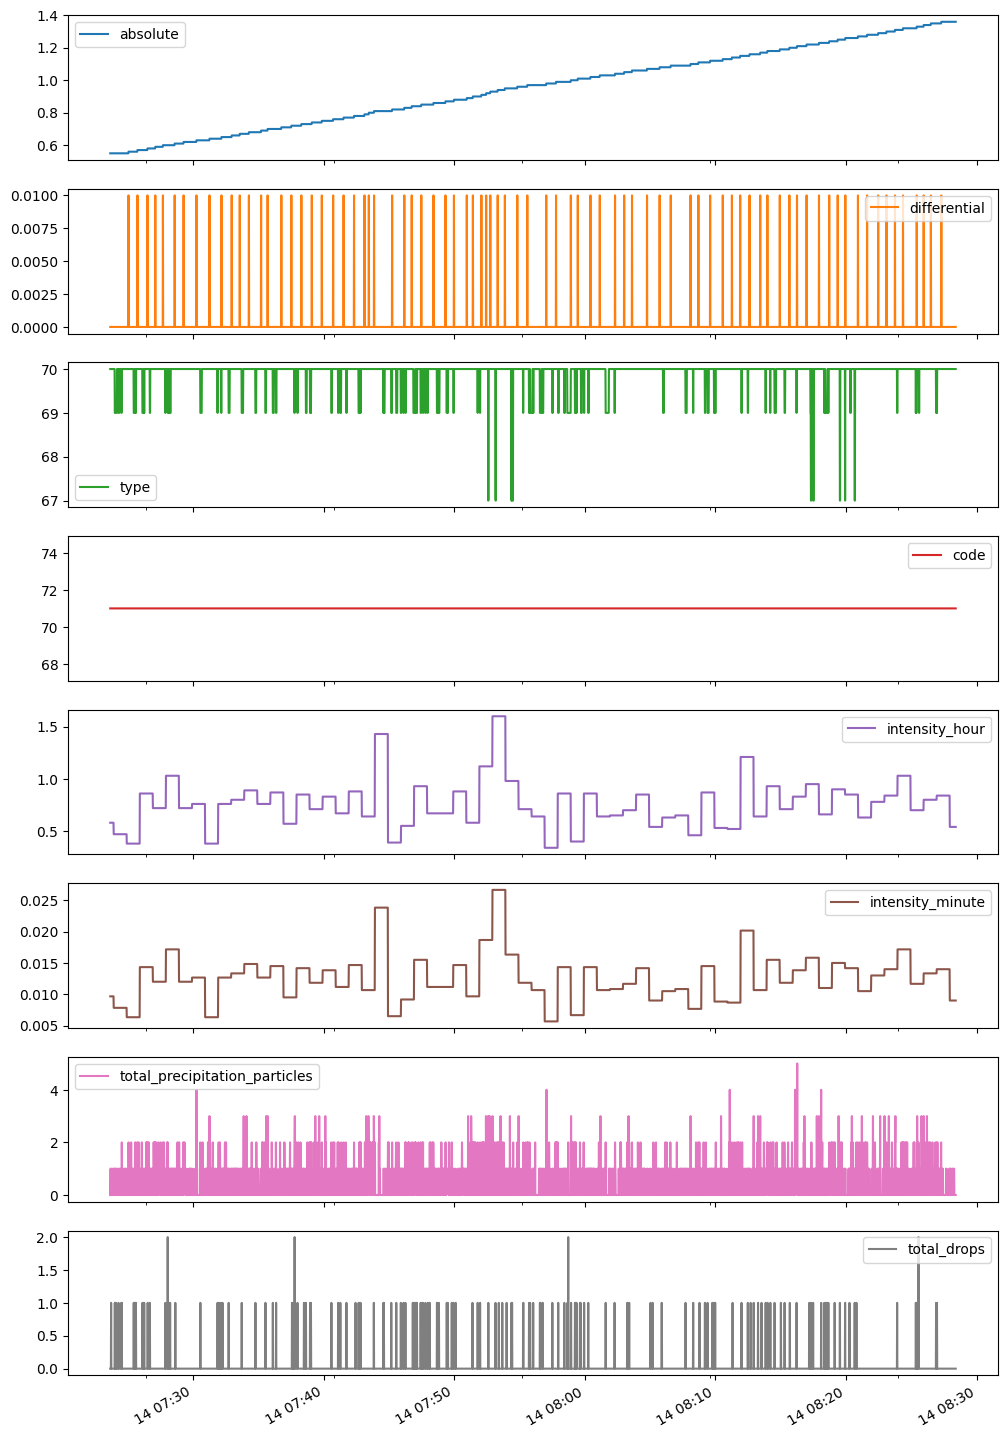

In [10]:
df.precipitation.loc[:, "absolute":"total_drops"].plot(subplots=True, figsize=(12, 20))
# df.precipitation.intensity_hour.hist()

#### Load Pointclouds